In [1]:
import numpy as np
import shap
import pandas as pd
import joblib
import matplotlib.pyplot as plt

/home/marysia/Documents/GitHub/MRI_machine_learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
cd ..

/home/marysia/Documents/GitHub/MRI_machine_learning


In [3]:
atlas = 'a2009'
model_name = 'svm'
data_type = 'positive'
valid='0'



In [8]:
#shap_values = np.load(f'shap_values_all_{atlas}.npy')
X_test =  pd.read_csv(f'data/preprocessed_atlas/{data_type}_norm_confirmed_{atlas}/leave_out.csv', sep='\t')

In [9]:
model_path=f'models/{atlas}/{model_name}_{data_type}_valid_{valid}'
clf= joblib.load( f'{model_path}/model_train_nr_0.pkl')

                                     feature_name      mean  std_importance
68                   ASEG-4th-Ventricle_normRange  1.245329        0.070942
1         Volume of ventricles and choroid plexus  1.098651        0.093184
93            ASEG-Left-Accumbens-area_Volume_mm3  0.765469        0.084898
57                  ASEG-3rd-Ventricle_Volume_mm3  0.668818        0.070932
242   ASEG-Right-non-WM-hypointensities_normRange  0.625070        0.044233
32          ASEG-Left-Cerebellum-Cortex_normRange  0.542325        0.030074
56                   ASEG-Left-Pallidum_normRange  0.531404        0.133977
26    ASEG-Left-Cerebellum-White-Matter_normRange  0.528370        0.058873
134  ASEG-Right-Cerebellum-White-Matter_normRange  0.519664        0.043002
140        ASEG-Right-Cerebellum-Cortex_normRange  0.507020        0.041688
147                 ASEG-Right-Caudate_Volume_mm3  0.497169        0.077482
38                   ASEG-Left-Thalamus_normRange  0.481954        0.043185
152         

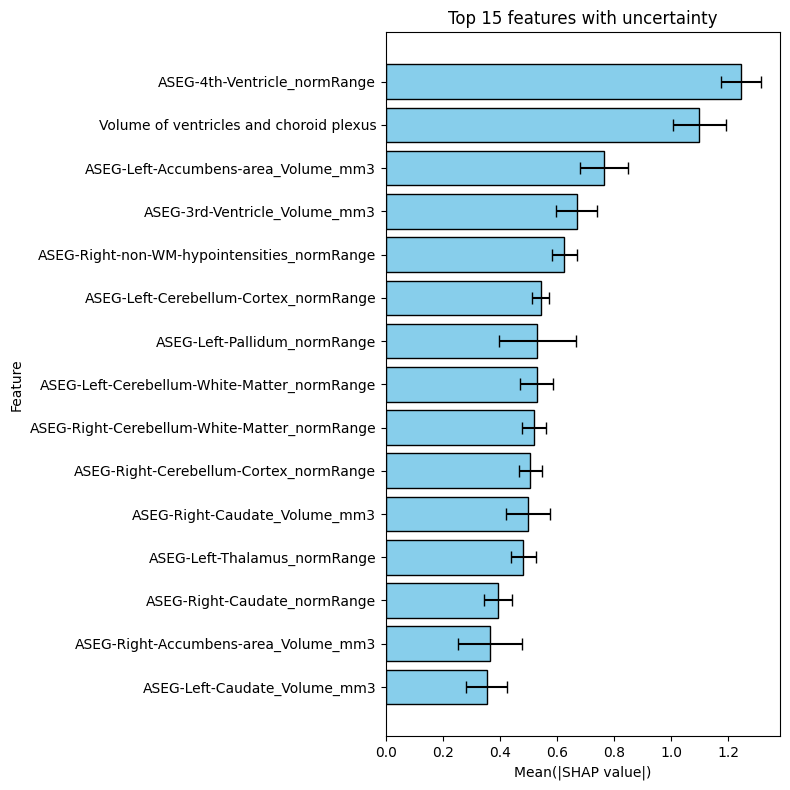

In [75]:
model_name ='svm'
all_importances = []

for i in range(5):
    shap_values = np.load(f'{model_path}/{model_name}_shap_values_{i}.npy')
    mean_abs = np.abs(shap_values).mean(axis=0)
    all_importances.append(mean_abs)
    #print(shap_values.shape)
    #shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)
    #shap.summary_plot(shap_values, X_test, max_display=20)

all_importances = np.array(all_importances)

mean_importance = all_importances.mean(axis=0)
std_importance = all_importances.std(axis=0)


ranking_df = pd.DataFrame({
    'feature_name': X_test.columns,
    'mean': mean_importance,
    'std_importance': std_importance
}).sort_values('mean', ascending=False)

print(ranking_df.head(20))

top_n = 15

ranking_df = ranking_df.head(top_n)
ranking_df = ranking_df.iloc[::-1]  # odwrócenie kolejności, żeby największe były na górze na wykresie

# Wykres
plt.figure(figsize=(8, 8))
plt.barh(
    ranking_df['feature_name'],
    ranking_df['mean'],
    xerr=ranking_df['std_importance'],
    capsize=4,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Mean(|SHAP value|)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features with uncertainty")
plt.tight_layout()
plt.show()


#ranking_df.to_csv('ASEG_shap.csv', sep='\t', index=True)

In [78]:
atlas = 'a2009'
model_name = 'svm'
data_type = 'positive'
valid='0'


shap_values = np.load(f'shap_values_all_{atlas}.npy')
X_test =  pd.read_csv(f'data/preprocessed_atlas/{data_type}_norm_confirmed_{atlas}/leave_out.csv', sep='\t')
model_path=f'models/{atlas}/{model_name}_{data_type}_valid_{valid}'
clf = joblib.load( f'{model_path}/model_train_nr_0.pkl')

                                    feature_name      mean  std_importance
364   A2009-ctx-lh-S_circular_insula_inf_GrayVol  0.360618        0.015473
415     A2009-ctx-lh-S_parieto_occipital_GrayVol  0.302132        0.065211
365  A2009-ctx-lh-S_circular_insula_inf_ThickAvg  0.297773        0.051790
343            A2009-ctx-lh-Lat_Fis-post_GrayVol  0.296076        0.085131
132            A2009-ctx-rh-S_calcarine_ThickStd  0.291450        0.029444
33                A2009-ctx-rh-G_cuneus_ThickStd  0.274657        0.058638
334       A2009-ctx-lh-G_temporal_middle_GrayVol  0.267761        0.053080
295    A2009-ctx-lh-G_pariet_inf-Angular_GrayVol  0.262253        0.063090
40     A2009-ctx-rh-G_front_inf-Triangul_GrayVol  0.247308        0.105687
122           A2009-ctx-rh-Lat_Fis-post_ThickAvg  0.232599        0.058406
160             A2009-ctx-rh-S_front_sup_GrayVol  0.226465        0.029311
19   A2009-ctx-rh-G_and_S_cingul-Mid-Ant_GrayVol  0.221958        0.074894
278     A2009-ctx-lh-G_oc

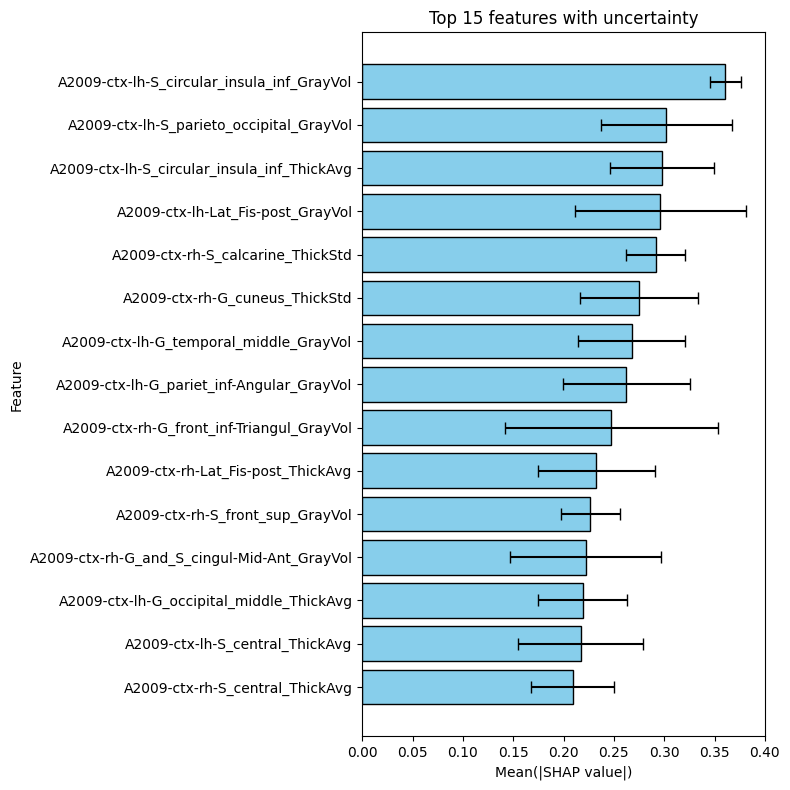

In [81]:
model_name ='svm'
all_importances = []

for i in range(5):
    shap_values = np.load(f'{model_path}/{model_name}_shap_values_{i}.npy')
    mean_abs = np.abs(shap_values).mean(axis=0)
    all_importances.append(mean_abs)
    #print(shap_values.shape)
    #shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)
    #shap.summary_plot(shap_values, X_test, max_display=20)

all_importances = np.array(all_importances)

mean_importance = all_importances.mean(axis=0)
std_importance = all_importances.std(axis=0)


ranking_df = pd.DataFrame({
    'feature_name': X_test.columns,
    'mean': mean_importance,
    'std_importance': std_importance
}).sort_values('mean', ascending=False)

print(ranking_df.head(20))

top_n = 15

ranking_df = ranking_df.head(top_n)
ranking_df = ranking_df.iloc[::-1]  # odwrócenie kolejności, żeby największe były na górze na wykresie

# Wykres
plt.figure(figsize=(8, 8))
plt.barh(
    ranking_df['feature_name'],
    ranking_df['mean'],
    xerr=ranking_df['std_importance'],
    capsize=4,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Mean(|SHAP value|)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features with uncertainty")
plt.tight_layout()
plt.show()


#ranking_df.to_csv('ASEG_shap.csv', sep='\t', index=True)

In [10]:
atlas = 'a2009'
model_name = 'svm'
data_type = 'positive'
valid='0'


shap_values = np.load(f'shap_values_all_{atlas}.npy')
X_test =  pd.read_csv(f'data/preprocessed_atlas/{data_type}_norm_confirmed_{atlas}/leave_out.csv', sep='\t')
model_path=f'models/{atlas}/{model_name}_{data_type}_valid_{valid}'
clf = joblib.load( f'{model_path}/model_train_nr_0.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'shap_values_all_a2009.npy'

/tmp/ipykernel_19062/2655864340.py:6: RuntimeWarning: Mean of empty slice.
  mean_abs = np.abs(shap_values).mean(axis=0)
/home/marysia/Documents/GitHub/MRI_machine_learning/.venv/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


                                   feature_name  mean  std_importance
0                                           sex   NaN             NaN
1                                          male   NaN             NaN
2                                        female   NaN             NaN
3                                           age   NaN             NaN
4                                        weight   NaN             NaN
5                                         hight   NaN             NaN
6                                    identifier   NaN             NaN
7                                norm_confirmed   NaN             NaN
8     A2009-ctx-rh-G_and_S_frontomargin_GrayVol   NaN             NaN
9    A2009-ctx-rh-G_and_S_frontomargin_ThickAvg   NaN             NaN
10   A2009-ctx-rh-G_and_S_frontomargin_ThickStd   NaN             NaN
11   A2009-ctx-rh-G_and_S_occipital_inf_GrayVol   NaN             NaN
12  A2009-ctx-rh-G_and_S_occipital_inf_ThickAvg   NaN             NaN
13  A2009-ctx-rh-G_a

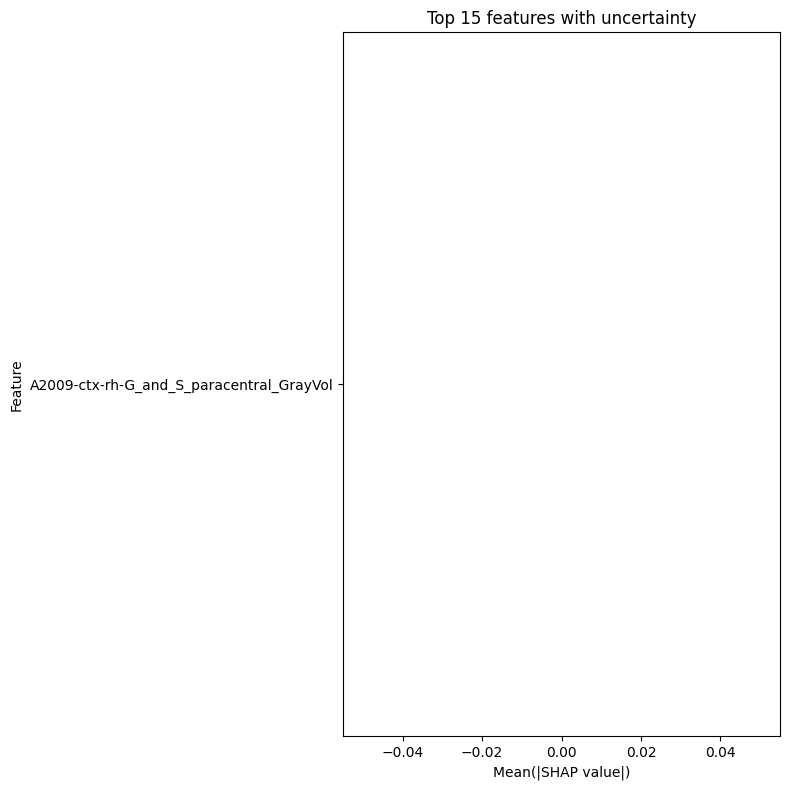

In [11]:
model_name ='svm'
all_importances = []

for i in range(5):
    shap_values = np.load(f'{model_path}/{model_name}_shap_values_{i}.npy')
    mean_abs = np.abs(shap_values).mean(axis=0)
    all_importances.append(mean_abs)
    #print(shap_values.shape)
    #shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)
    #shap.summary_plot(shap_values, X_test, max_display=20)

all_importances = np.array(all_importances)

mean_importance = all_importances.mean(axis=0)
std_importance = all_importances.std(axis=0)


ranking_df = pd.DataFrame({
    'feature_name': X_test.columns,
    'mean': mean_importance,
    'std_importance': std_importance
}).sort_values('mean', ascending=False)

print(ranking_df.head(20))

top_n = 15

ranking_df = ranking_df.head(top_n)
ranking_df = ranking_df.iloc[::-1]  # odwrócenie kolejności, żeby największe były na górze na wykresie

# Wykres
plt.figure(figsize=(8, 8))
plt.barh(
    ranking_df['feature_name'],
    ranking_df['mean'],
    xerr=ranking_df['std_importance'],
    capsize=4,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Mean(|SHAP value|)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features with uncertainty")
plt.tight_layout()
plt.show()


#ranking_df.to_csv('ASEG_shap.csv', sep='\t', index=True)

In [15]:
shap_values_test = np.load(f'models/ASEG/svm_positive_valid_0/svm_shap_values_0.npy')

In [16]:
shap_values_test

array([[ 0.        ,  2.01753762,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -1.27370001,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  3.37015819,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -1.43850856,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [6]:
model_features = clf.feature_names_in_
print(len(model_features))

original_cols = X_test.columns
model_cols = model_features

# brakujące w modelu
extra_cols = [col for col in original_cols if col not in model_cols]
print("Columns in X_test but not in model:", extra_cols)

# brakujące w X_test (jeśli jakieś)
missing_cols = [col for col in model_cols if col not in original_cols]
print("Columns required by model but not in X_test:", missing_cols)

445
Columns in X_test but not in model: ['sex', 'female', 'age', 'weight', 'hight', 'identifier', 'norm_confirmed']
Columns required by model but not in X_test: []


In [80]:
X_test = X_test.drop(columns = ['sex', 'female', 'age', 'weight', 'hight', 'identifier', 'norm_confirmed'])

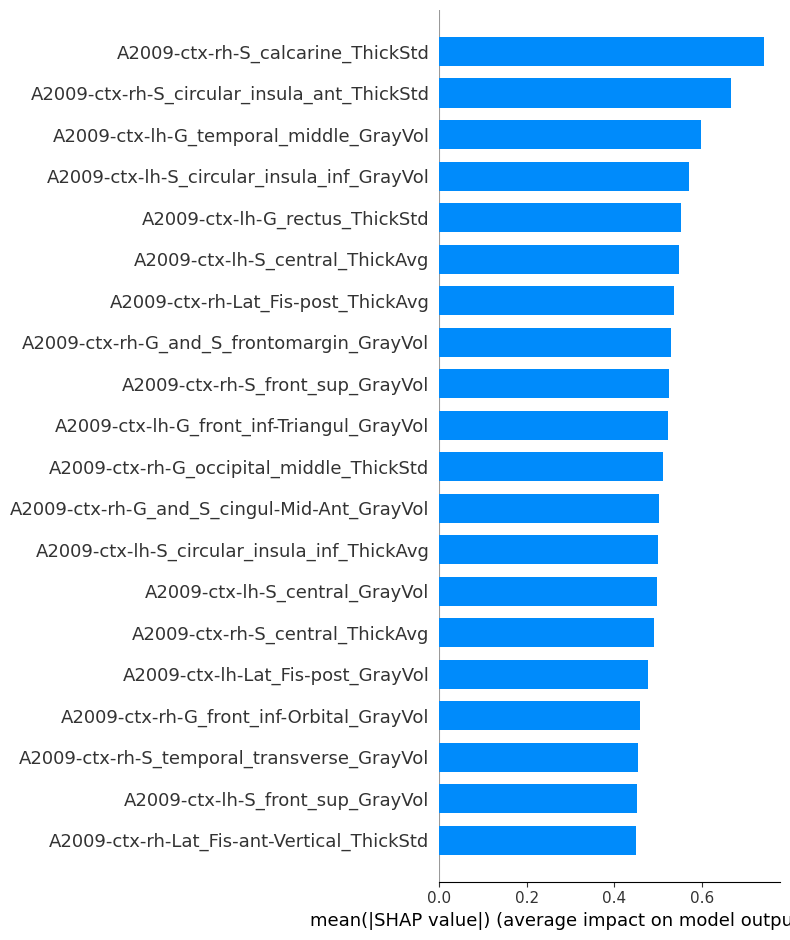

In [22]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

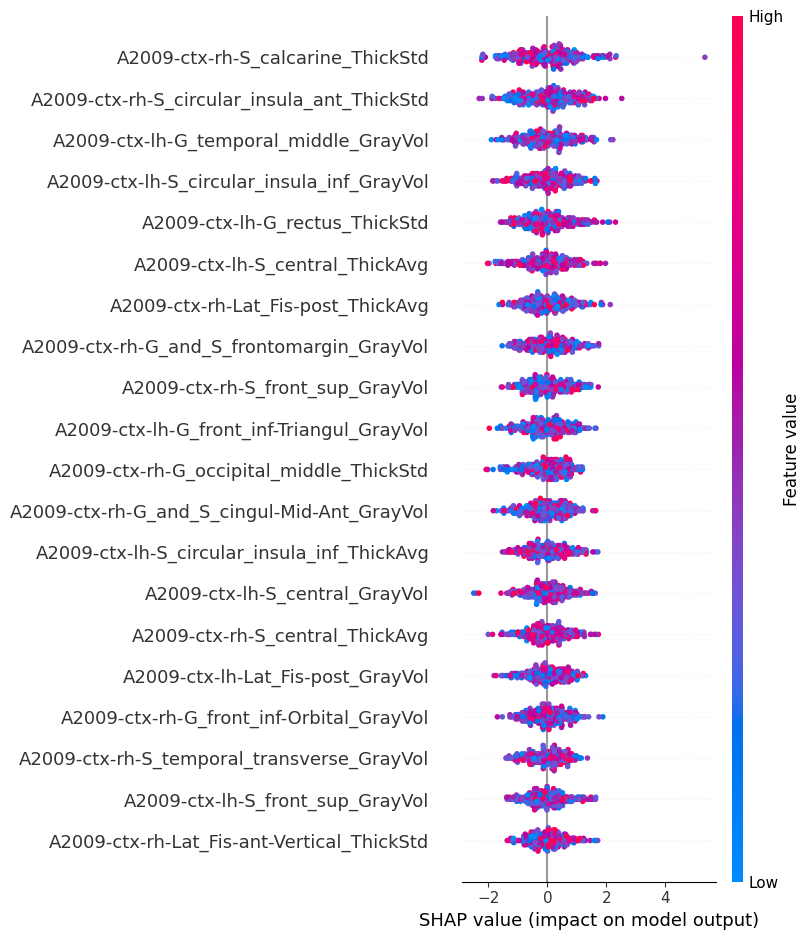

In [23]:
shap.summary_plot(shap_values, X_test, max_display=20)

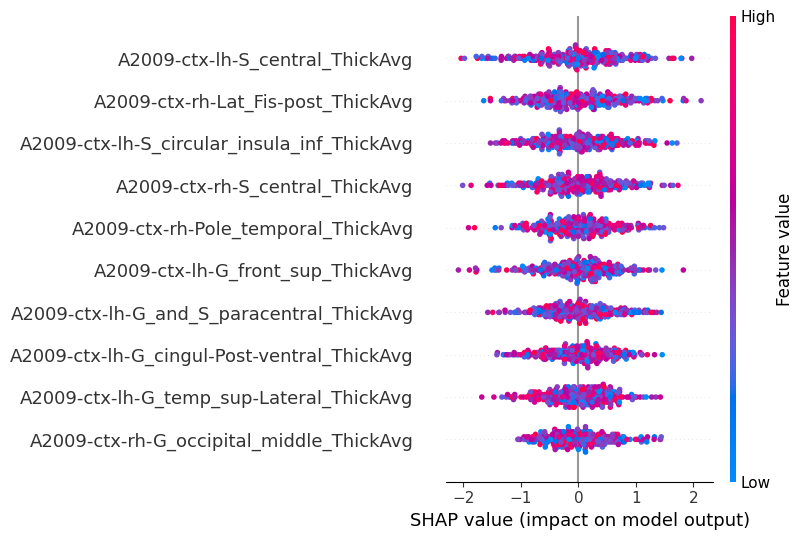

In [9]:
mask = X_test.columns.str.contains("ThickAvg")
X_thick = X_test.loc[:, mask]
shap_thick = shap_values[:, mask]

# 2. Średnia bezwzględna SHAP dla tych cech
mean_abs_shap = np.abs(shap_thick).mean(axis=0)

# 3. Indeksy 10 najważniejszych cech (w podmacierzy!)
top10_idx = mean_abs_shap.argsort()[::-1][:10]

# 4. Wybranie tych samych cech w obu macierzach w tej samej kolejności
X_top10 = X_thick.iloc[:, top10_idx]
shap_top10 = shap_thick[:, top10_idx]

# 5. Summary plot
shap.summary_plot(shap_top10, X_top10, max_display=10)

In [17]:
shap_values.shape

(312, 445)

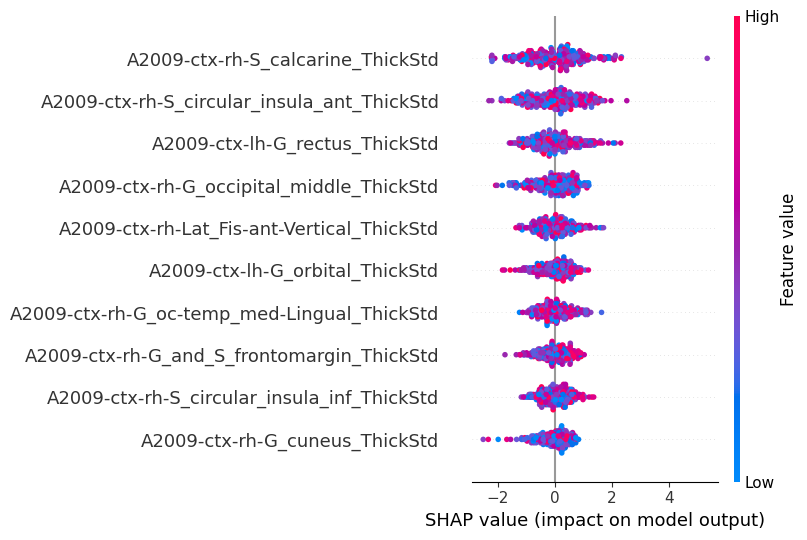

In [68]:
mask = X_test.columns.str.contains("ThickStd")
mean_abs_shap = np.abs(shap_values[:, mask]).mean(axis=0)

# Indeksy 10 najważniejszych cech
top10_idx = mean_abs_shap.argsort()[::-1][:10]

X_top10 = X_test.loc[:, mask].iloc[:, top10_idx]
shap_top10 = shap_values[:, mask][:, top10_idx]

shap.summary_plot(shap_top10, X_top10, max_display=10)

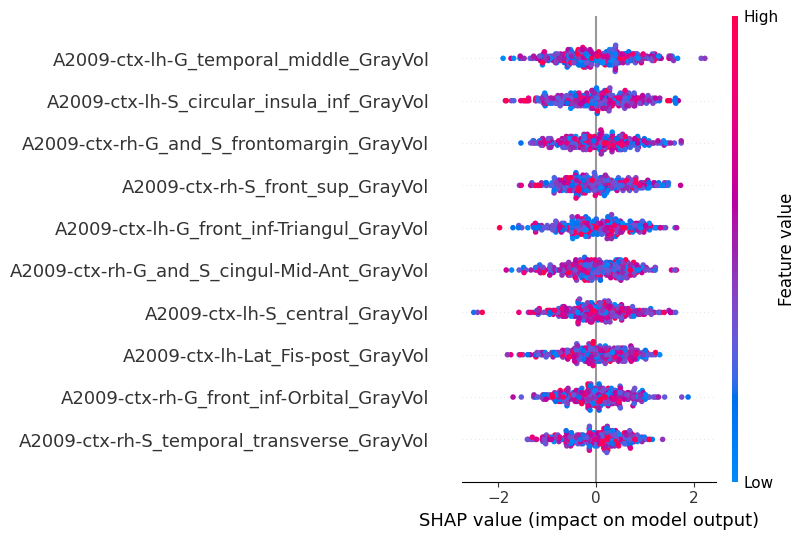

In [69]:
mask = X_test.columns.str.contains("GrayVol")
mean_abs_shap = np.abs(shap_values[:, mask]).mean(axis=0)

# Indeksy 10 najważniejszych cech
top10_idx = mean_abs_shap.argsort()[::-1][:10]

X_top10 = X_test.loc[:, mask].iloc[:, top10_idx]
shap_top10 = shap_values[:, mask][:, top10_idx]

shap.summary_plot(shap_top10, X_top10, max_display=10)

In [15]:
col_nonzero_counts = np.count_nonzero(shap_values, axis=0)
# shape = (n_cols,)

# liczba niezerowych w każdym wierszu
row_nonzero_counts = np.count_nonzero(shap_values, axis=1)
# shape = (n_rows,)

print("Liczba niezerowych SHAP w kolumnach:", col_nonzero_counts)
print("Liczba niezerowych SHAP w wierszach: ", row_nonzero_counts)


Liczba niezerowych SHAP w kolumnach: [ 8 39  0 36 21  9  0  0 22  1  1  0  0  0  0  0 30  1  0 57  1  0  1 14
  3  2  0  0  1  3  1  6  1 28  2  0  4 55  0  0 21  1  0  0  0  0  8 16
  0  1  0  1  3  0  1  7 45 57  2 14  0  0  7  8 14  0 21  0  0 25  4  3
  0 25  0  1  9  0  4 14  0  0  0  2  0  0  1  7 10  2  2  1 16  0 28  0
 21  0  4  0  0 24  0  0  3  0  0  8  0  0 29  0  0  0 12  0  0  3  0  0
 13 19 53  3  6  0  0  7 33  0 20 10 73  5 43  0  0  0  2  0  0 58 41 14
 11  2  0  0  0  0  0  1  0  0  0  0  0  0  0  2 44  0  1  1  8  0  0  4
 12  6  0  0 31  2  1  0  0  0  1  0  2 24  4  3  0  1  3 16  1  0  0  0
  0  0  7  0  7 15  1  0  0  1  0  0  3  2  0  0  0  0  8  0  2  0  0  2
  2 11  0  0 53  1  0 26  3  0  2  0  0  0 39  0  3  0  0  4  2  4  5  1
  4 35 12  7  0  1  2  4 18  0 40 41  0  0  0  0  4  1  0  1  0  5 67  3
 31  1  0  0  0 42  2  0  6  0  0 21  0  0 34  9  1 25  0 10 10  0  0  3
  2  1  2  7  0  7 38 27 24 23  3  2  0  0  0  0 11  0  0 10  0 17  2  2
  0  8  0 46  

In [48]:
atlas = 'ASEG'
model_name = 'svm'
data_type = 'positive'
valid='0'

In [49]:
shap_values = np.load(f'shap_values_all_{atlas}.npy')
X_test =  pd.read_csv(f'data/preprocessed_atlas/{data_type}_norm_confirmed_{atlas}/leave_out.csv', sep='\t')

In [50]:
model_path=f'models/{atlas}/{model_name}_{data_type}_valid_{valid}'
clf= joblib.load( f'{model_path}/model_train_nr_0.pkl')
X_test = X_test.drop(columns = ['sex', 'female', 'age', 'weight', 'hight', 'identifier', 'norm_confirmed'])

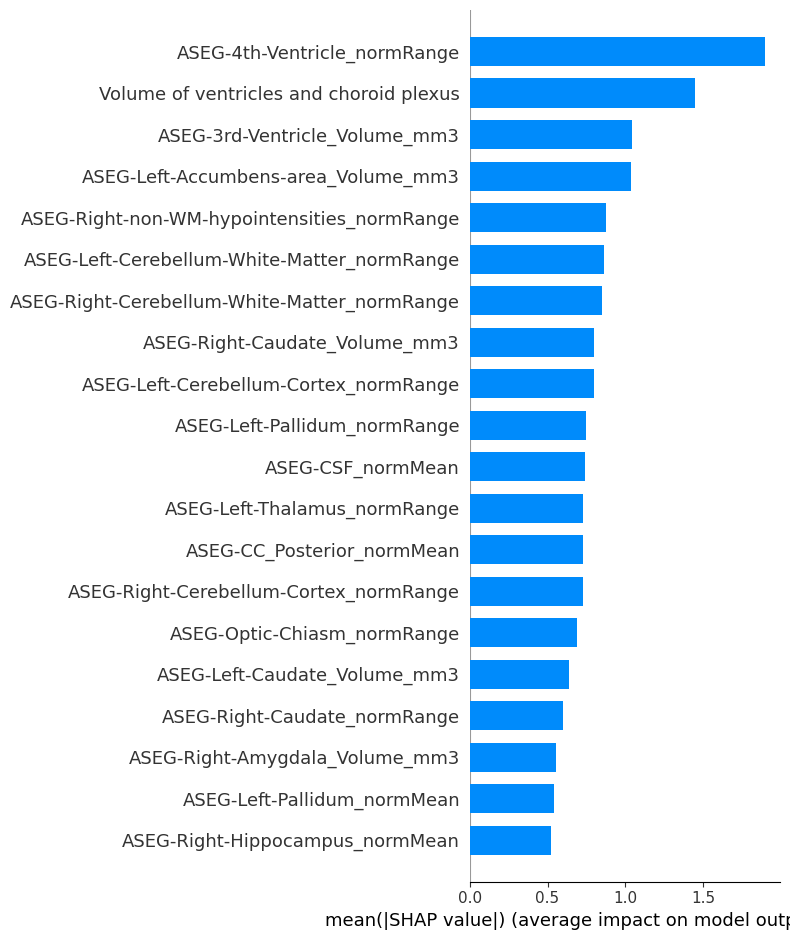

In [29]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

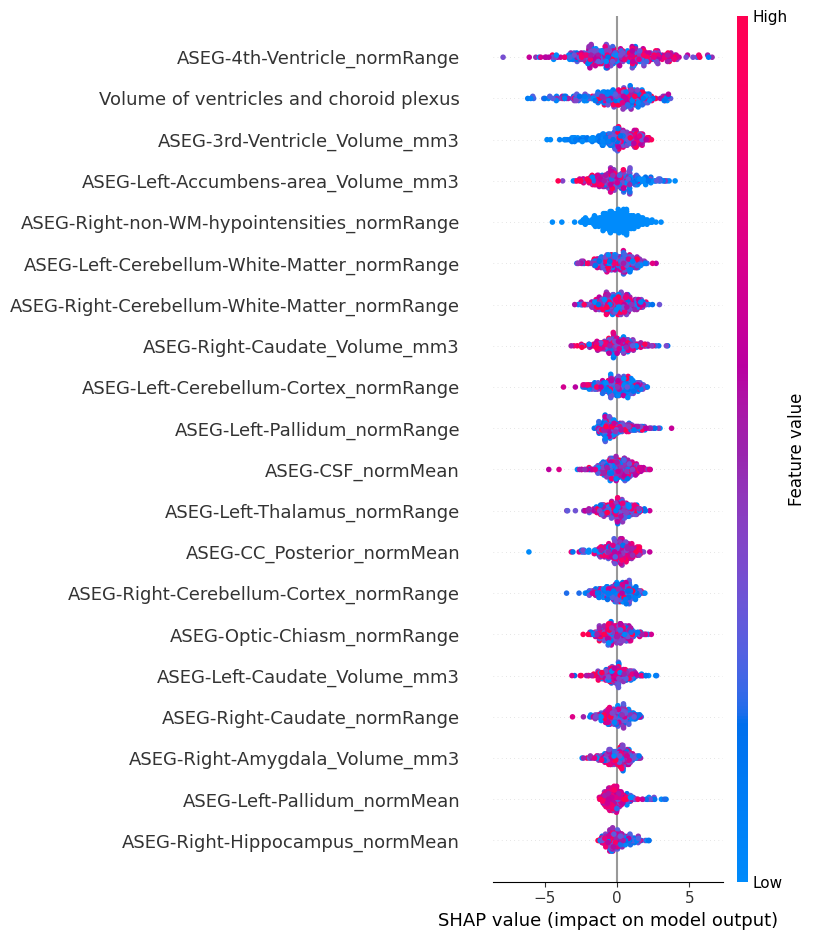

In [30]:
shap.summary_plot(shap_values, X_test, max_display=20)

In [ ]:
shap_values_summed = shap_values.sum(axis=0)


In [51]:
feature_to_remove = "ASEG-Right-non-WM-hypointensities_normRange"

# Znajdź indeks tej kolumny
feature_index = X_test.columns.get_loc(feature_to_remove)

# Usuń kolumnę z shap_values
shap_values_new = np.delete(shap_values, feature_index, axis=1)

# Usuń kolumnę z X_test
X_test_new = X_test.drop(columns=[feature_to_remove])

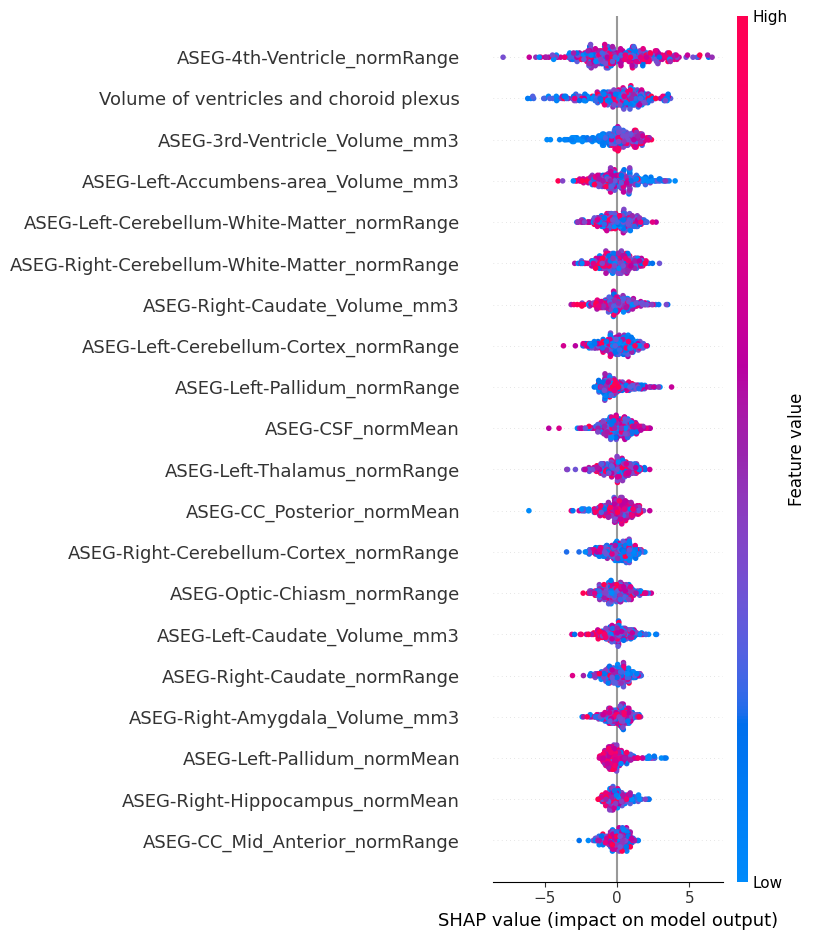

In [52]:
shap.summary_plot(shap_values_new, X_test_new, max_display=20)

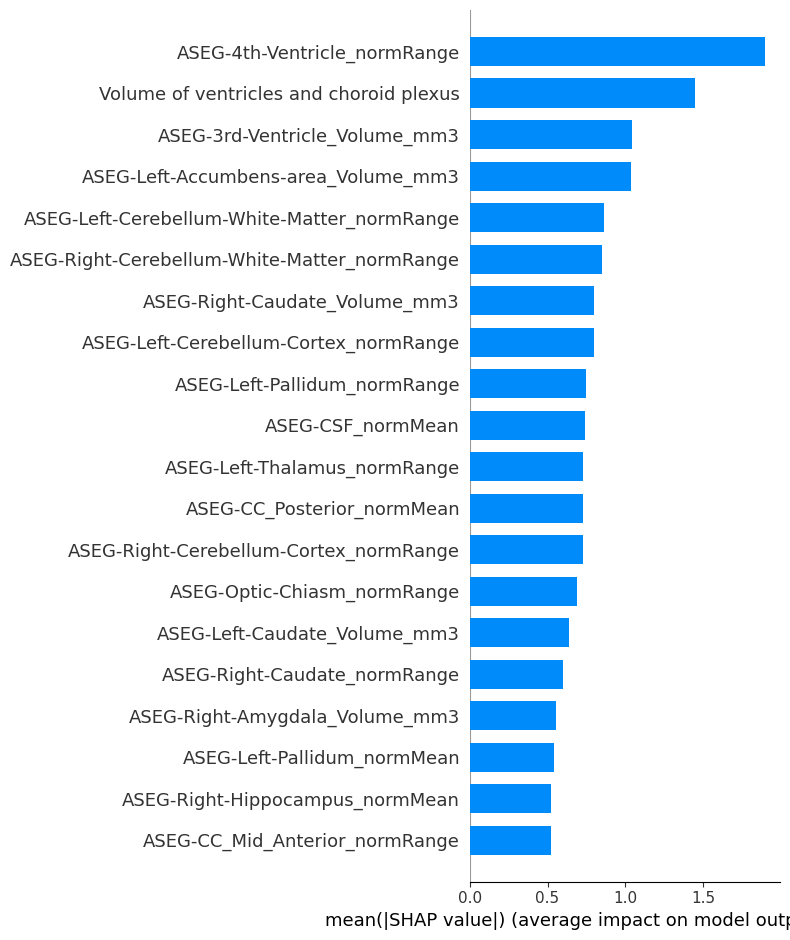

In [55]:
shap.summary_plot(shap_values_new, X_test_new, plot_type="bar", max_display=20)

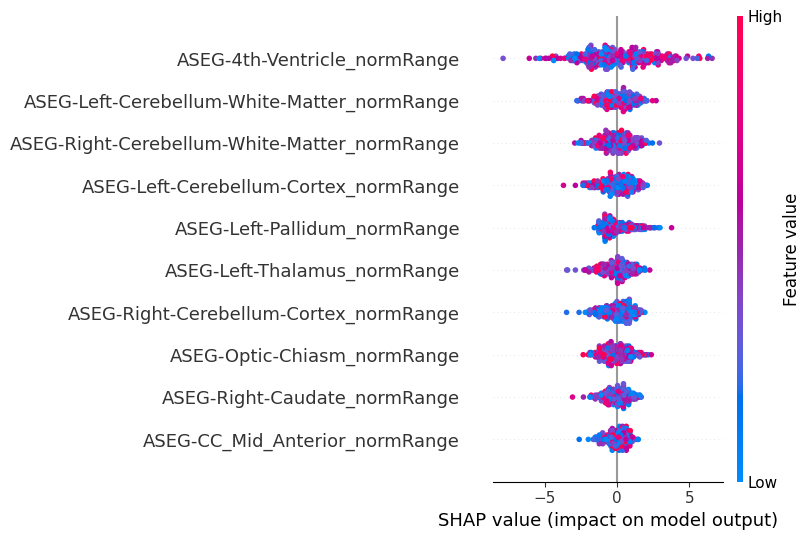

In [54]:
mask = X_test_new.columns.str.contains("normRange")
X_thick = X_test_new.loc[:, mask]
shap_thick = shap_values_new[:, mask]

# 2. Średnia bezwzględna SHAP dla tych cech
mean_abs_shap = np.abs(shap_thick).mean(axis=0)

# 3. Indeksy 10 najważniejszych cech (w podmacierzy!)
top10_idx = mean_abs_shap.argsort()[::-1][:10]

# 4. Wybranie tych samych cech w obu macierzach w tej samej kolejności
X_top10 = X_thick.iloc[:, top10_idx]
shap_top10 = shap_thick[:, top10_idx]

# 5. Summary plot
shap.summary_plot(shap_top10, X_top10, max_display=10)

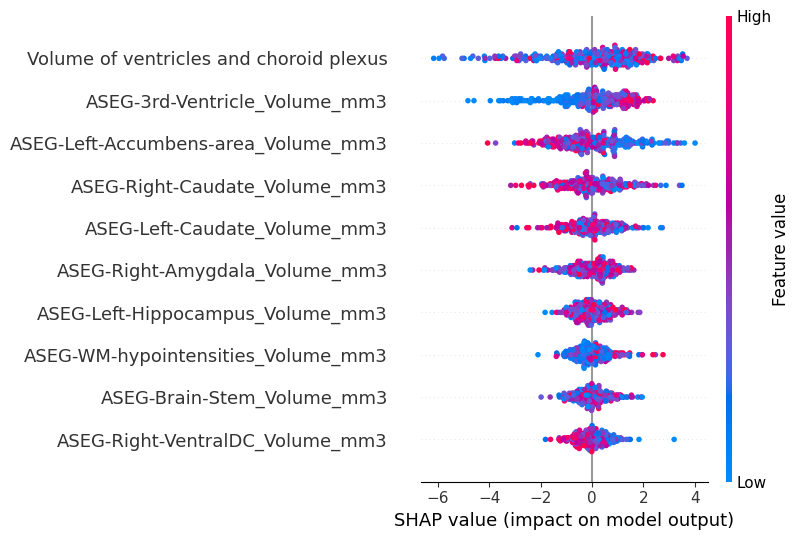

In [56]:
mask = X_test.columns.str.contains("Volume")
X_thick = X_test.loc[:, mask]
shap_thick = shap_values[:, mask]

# 2. Średnia bezwzględna SHAP dla tych cech
mean_abs_shap = np.abs(shap_thick).mean(axis=0)

# 3. Indeksy 10 najważniejszych cech (w podmacierzy!)
top10_idx = mean_abs_shap.argsort()[::-1][:10]

# 4. Wybranie tych samych cech w obu macierzach w tej samej kolejności
X_top10 = X_thick.iloc[:, top10_idx]
shap_top10 = shap_thick[:, top10_idx]

# 5. Summary plot
shap.summary_plot(shap_top10, X_top10, max_display=10)

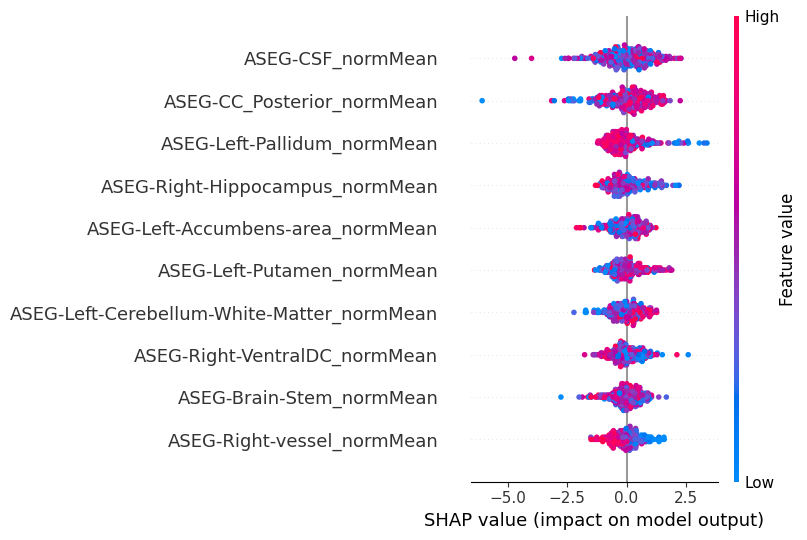

In [47]:
mask = X_test.columns.str.contains("normMean")
X_thick = X_test.loc[:, mask]
shap_thick = shap_values[:, mask]

# 2. Średnia bezwzględna SHAP dla tych cech
mean_abs_shap = np.abs(shap_thick).mean(axis=0)

# 3. Indeksy 10 najważniejszych cech (w podmacierzy!)
top10_idx = mean_abs_shap.argsort()[::-1][:10]

# 4. Wybranie tych samych cech w obu macierzach w tej samej kolejności
X_top10 = X_thick.iloc[:, top10_idx]
shap_top10 = shap_thick[:, top10_idx]

# 5. Summary plot
shap.summary_plot(shap_top10, X_top10, max_display=10)

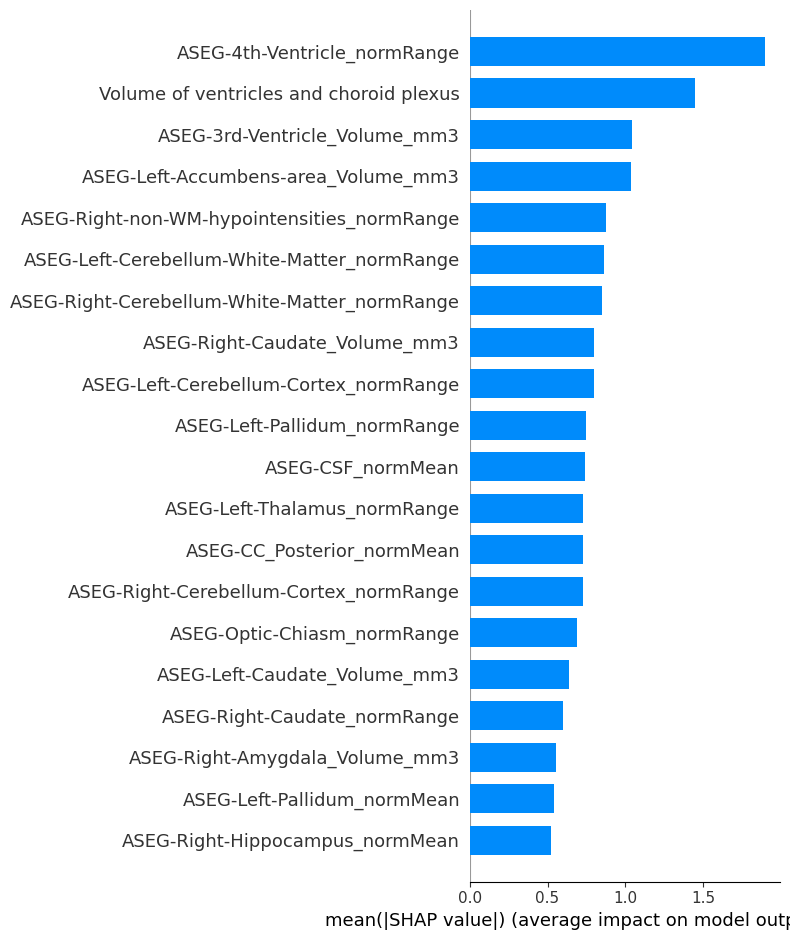

In [43]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)